In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
pd.set_option('display.max_columns', None)

from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

In [2]:
business = pd.read_csv('business.csv')
clean = pd.read_csv('Clean_Dataset.csv')
economy = pd.read_csv('economy.csv')

In [3]:
print(clean.info())
clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  str    
 2   flight            300153 non-null  str    
 3   source_city       300153 non-null  str    
 4   departure_time    300153 non-null  str    
 5   stops             300153 non-null  str    
 6   arrival_time      300153 non-null  str    
 7   destination_city  300153 non-null  str    
 8   class             300153 non-null  str    
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 42.9 MB
None


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
print(business.info())
business.head()

<class 'pandas.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        93487 non-null  str  
 1   airline     93487 non-null  str  
 2   ch_code     93487 non-null  str  
 3   num_code    93487 non-null  int64
 4   dep_time    93487 non-null  str  
 5   from        93487 non-null  str  
 6   time_taken  93487 non-null  str  
 7   stop        93487 non-null  str  
 8   arr_time    93487 non-null  str  
 9   to          93487 non-null  str  
 10  price       93487 non-null  str  
dtypes: int64(1), str(10)
memory usage: 15.6 MB
None


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [5]:
print(economy.info())
economy.head()

<class 'pandas.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   date        206774 non-null  str  
 1   airline     206774 non-null  str  
 2   ch_code     206774 non-null  str  
 3   num_code    206774 non-null  int64
 4   dep_time    206774 non-null  str  
 5   from        206774 non-null  str  
 6   time_taken  206774 non-null  str  
 7   stop        206774 non-null  str  
 8   arr_time    206774 non-null  str  
 9   to          206774 non-null  str  
 10  price       206774 non-null  str  
dtypes: int64(1), str(10)
memory usage: 33.8 MB
None


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [6]:
#add class col before combining
economy['class'] = 'Economy'
business['class'] = 'Business'
flights = pd.concat([economy, business], axis= 0)
flights.shape

(300261, 12)

In [7]:
flights['date'] = pd.to_datetime(flights['date'], format = '%d-%m-%Y')
flights['dep_time'] = pd.to_datetime(flights['dep_time']).dt.time
flights['arr_time'] = pd.to_datetime(flights['arr_time']).dt.time

C:\Users\Yooniversity 2.0\AppData\Local\Temp\ipykernel_30424\1520429542.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights['dep_time'] = pd.to_datetime(flights['dep_time']).dt.time
C:\Users\Yooniversity 2.0\AppData\Local\Temp\ipykernel_30424\1520429542.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flights['arr_time'] = pd.to_datetime(flights['arr_time']).dt.time


In [8]:
#Change price from string to int
flights['price'] = flights['price'].str.replace(',', '').astype(int)

#change time_taken to min
h = flights['time_taken'].str.extract(r'(\d+)h').fillna(0).astype(int)
m = flights['time_taken'].str.extract(r'(\d+)m').fillna(0).astype(int)
flights['time_taken'] = (h*60) + m

In [9]:
flights.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,130,non-stop,21:05:00,Mumbai,5953,Economy
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,140,non-stop,08:40:00,Mumbai,5953,Economy
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,130,non-stop,06:35:00,Mumbai,5956,Economy
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,135,non-stop,12:35:00,Mumbai,5955,Economy
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,140,non-stop,11:10:00,Mumbai,5955,Economy


Compare prices between classes

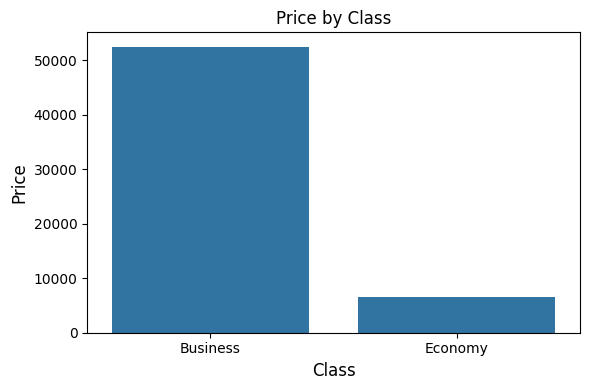

In [10]:
price_by_class = flights.groupby(['class'])['price'].mean().reset_index()

plt.figure(figsize = (6,4))

sns.barplot(price_by_class, 
            x = 'class', 
            y = 'price')

plt.title('Price by Class')
plt.xlabel("Class", fontsize = 12)
plt.ylabel('Price', fontsize = 12)

plt.tight_layout()

Check Price by Airline

<Figure size 1200x800 with 0 Axes>

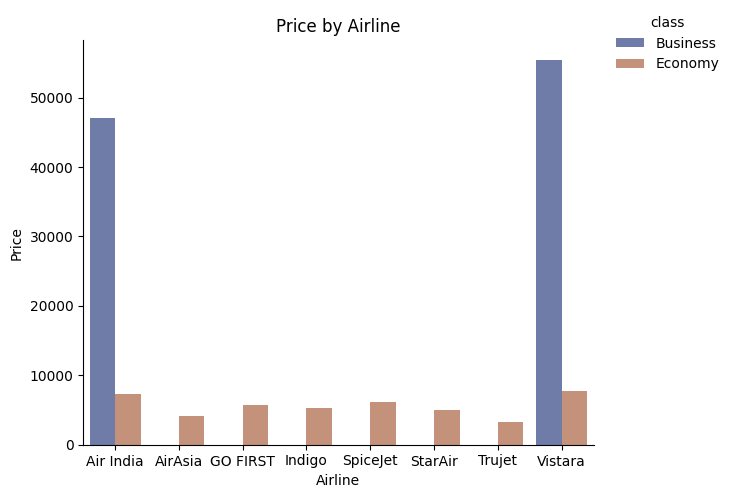

In [11]:
price_by_airline = flights.groupby(['airline', 'class'])['price'].mean().reset_index()

plt.figure(figsize = (12,8))
plot = sns.catplot(data = price_by_airline,
            kind = 'bar',
            x = 'airline',
            y = 'price',
            hue = 'class',
            palette='dark',
            alpha = .6)

sns.move_legend(plot, 'upper right', bbox_to_anchor=(1.2, 1))
plt.title("Price by Airline")
plt.ylabel('Price')
plt.xlabel('Airline')
plt.tight_layout()

See how economy price fluctuates by time of the year

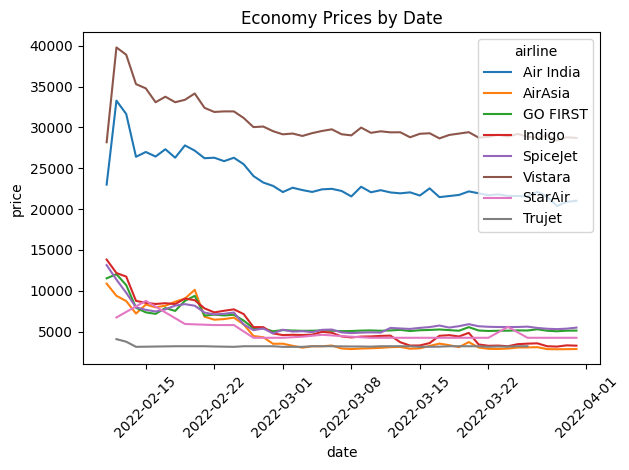

In [12]:
price_by_time=flights.groupby(['date', 'airline'])['price'].mean().reset_index()
#plt.figure(figsize = (12,8))
sns.lineplot(price_by_time,
            x = 'date',
            y = 'price',
            hue = 'airline')

plt.title('Economy Prices by Date')
plt.xticks(rotation = 45)
plt.tight_layout()


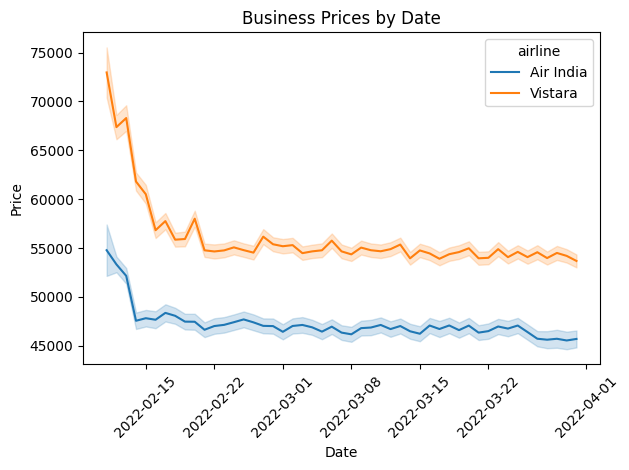

In [13]:
business_only = flights[flights['class'] == 'Business']

sns.lineplot(business_only,
            x = 'date',
            y = 'price',
            hue = 'airline',
            errorbar= ('se', 2))

plt.title('Business Prices by Date')
plt.xticks(rotation = 45)
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()

See how price fluctuates with departure time

In [14]:
flights['dep_float'] = flights['dep_time'].apply(lambda x: round(x.hour + x.minute/60,2))

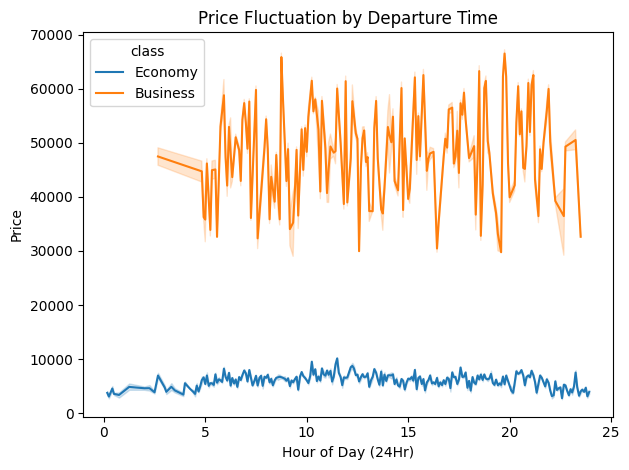

In [15]:
sns.lineplot(flights,
    x = 'dep_float',
    y = 'price',
    hue = 'class')

plt.title("Price Fluctuation by Departure Time")
plt.xlabel('Hour of Day (24Hr)')
plt.ylabel("Price")
plt.tight_layout()

See how distance(total flight time) relates to price

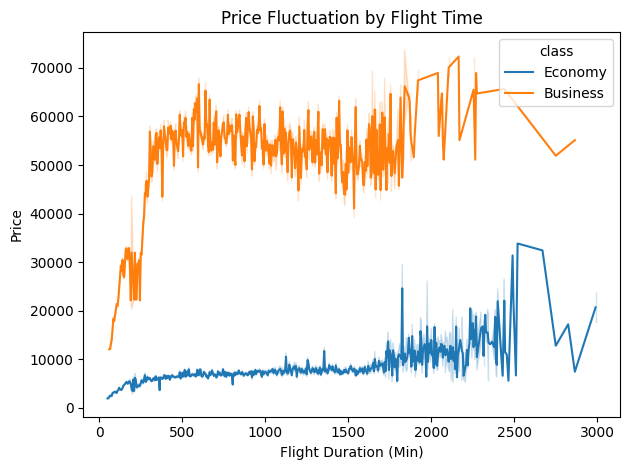

In [16]:
sns.lineplot(flights,
    x = 'time_taken',
    y = 'price',
    hue = 'class')

plt.title("Price Fluctuation by Flight Time")
plt.xlabel('Flight Duration (Min)')
plt.ylabel("Price")
plt.tight_layout()

Predict Price

In [17]:
flights['flight_id'] = flights['ch_code'] + '-' + flights['num_code'].astype(str)
flights['duration'] = round(flights['time_taken'] / 60,2)

In [18]:
flights.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,dep_float,flight_id,duration
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,130,non-stop,21:05:00,Mumbai,5953,Economy,18.92,SG-8709,2.17
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,140,non-stop,08:40:00,Mumbai,5953,Economy,6.33,SG-8157,2.33
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,130,non-stop,06:35:00,Mumbai,5956,Economy,4.42,I5-764,2.17
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,135,non-stop,12:35:00,Mumbai,5955,Economy,10.33,UK-995,2.25
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,140,non-stop,11:10:00,Mumbai,5955,Economy,8.83,UK-963,2.33


In [19]:
clean.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [20]:
# Check duplicates in each dataset on the merge keys
left_keys = ['airline', 'flight_id', 'from', 'to', 'class', 'price', 'duration']
right_keys = ['airline', 'flight', 'source_city', 'destination_city', 'class', 'price', 'duration']
print("Duplicates in flights:", flights.duplicated(subset=left_keys).sum())
print("Duplicates in clean:", clean[right_keys].duplicated().sum())

# See an example of a duplicated group
#these rows have a duplicate
flights[flights.duplicated(subset=left_keys, keep=False)].head(10)

Duplicates in flights: 231581
Duplicates in clean: 231494


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,dep_float,flight_id,duration
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,130,non-stop,21:05:00,Mumbai,5953,Economy,18.92,SG-8709,2.17
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,140,non-stop,08:40:00,Mumbai,5953,Economy,6.33,SG-8157,2.33
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,130,non-stop,06:35:00,Mumbai,5956,Economy,4.42,I5-764,2.17
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,135,non-stop,12:35:00,Mumbai,5955,Economy,10.33,UK-995,2.25
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,140,non-stop,11:10:00,Mumbai,5955,Economy,8.83,UK-963,2.33
5,2022-02-11,Vistara,UK,945,11:40:00,Delhi,140,non-stop,14:00:00,Mumbai,5955,Economy,11.67,UK-945,2.33
6,2022-02-11,Vistara,UK,927,09:30:00,Delhi,125,non-stop,11:35:00,Mumbai,6060,Economy,9.50,UK-927,2.08
8,2022-02-11,GO FIRST,G8,334,08:00:00,Delhi,130,non-stop,10:10:00,Mumbai,5954,Economy,8.00,G8-334,2.17
9,2022-02-11,GO FIRST,G8,336,14:20:00,Delhi,135,non-stop,16:35:00,Mumbai,5954,Economy,14.33,G8-336,2.25
10,2022-02-11,GO FIRST,G8,392,15:00:00,Delhi,135,non-stop,17:15:00,Mumbai,5954,Economy,15.00,G8-392,2.25


In [22]:
flights['_rank'] = flights.groupby(left_keys).cumcount()
clean['_rank'] = clean.groupby(right_keys).cumcount()

df = flights.merge(clean[['days_left', '_rank'] + right_keys],
                left_on= left_keys + ['_rank'],
                right_on = right_keys + ['_rank'],
                how  = 'inner')

cols_to_drop = ['flight', 'source_city', 'destination_city']
df = df.drop(columns = cols_to_drop)
print(f"Original Flights had {flights.shape[0]} rows")
print(f'Merged df has {df.shape[0]} rows')

Original Flights had 300261 rows
Merged df has 196088 rows


In [23]:
#0 = Monday 6 = Sunday
df['day_of_week'] = df['date'].dt.dayofweek

#cyclical encoding for time so hour 23 and 0 are seen as close
df['dep_hour_sin'] = np.sin(2 * np.pi * df['dep_float']/24)
df['dep_hour_cos'] = np.cos(2 * np.pi * df['dep_float']/ 24)

df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,dep_float,flight_id,duration,_rank,days_left,day_of_week,dep_hour_sin,dep_hour_cos
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,130,non-stop,21:05:00,Mumbai,5953,Economy,18.92,SG-8709,2.17,0,1,4,-0.971134,0.238533
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,140,non-stop,08:40:00,Mumbai,5953,Economy,6.33,SG-8157,2.33,0,1,4,0.996270,-0.086286
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,130,non-stop,06:35:00,Mumbai,5956,Economy,4.42,I5-764,2.17,0,1,4,0.915663,0.401948
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,135,non-stop,12:35:00,Mumbai,5955,Economy,10.33,UK-995,2.25,0,1,4,0.423409,-0.905939
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,140,non-stop,11:10:00,Mumbai,5955,Economy,8.83,UK-963,2.33,0,1,4,0.737867,-0.674947


In [24]:
num_cols = ['days_left', 'time_taken', 'dep_hour_sin', 'dep_hour_cos', 'day_of_week']
cat_cols = ['airline','class', 'stop', 'from', 'to']
y = ['price']

In [25]:
X = df[cat_cols + num_cols]
y = df[y]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((156870, 10), (39218, 10), (156870, 1), (39218, 1))

In [27]:
ct = ColumnTransformer([
    ('cat', OneHotEncoder(), cat_cols),
    ('num', StandardScaler(), num_cols)
])

models = models = [LogisticRegression(), RandomForestRegressor(n_estimators=100, random_state=42), GradientBoostingRegressor()]

results = []

for model in models:
    print(f'Training {model}')
    pipeline = Pipeline([
        ('preprocessor', ct),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    #calculate metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model_Name': model.__class__.__name__,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'Model': pipeline
    })



Training LogisticRegression()


c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training RandomForestRegressor(random_state=42)


c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training GradientBoostingRegressor()


c:\Users\Yooniversity 2.0\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_gb.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [30]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = 'RMSE', ascending= True)
results_df

,Model_Name,MSE,RMSE,R2 Score,Model
1,RandomForestRegressor,7.175404e+06,2678.694473,0.987613,"(ColumnTransformer(transformers=[('cat', OneHo..."
2,GradientBoostingRegressor,2.520763e+07,5020.719852,0.956483,"(ColumnTransformer(transformers=[('cat', OneHo..."
0,LogisticRegression,3.223064e+07,5677.203188,0.944359,"(ColumnTransformer(transformers=[('cat', OneHo..."


See how predicted prices compare to real price using best model

In [33]:
best_model = results_df['Model'].iloc[0]

y_pred = best_model.predict(X_test)
X_test['predicted_price'] = y_pred
X_test['actual_price'] = y_test
X_test.sample(10)

,airline,class,stop,from,to,days_left,time_taken,dep_hour_sin,dep_hour_cos,day_of_week,predicted_price,actual_price
132107,Indigo,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Chennai,Kolkata,47,520,0.151261,-0.988494,1,3421.290000,3219
149736,Vistara,Business,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Mumbai,Bangalore,6,480,-0.109734,-0.993961,2,56534.200000,62045
186038,Vistara,Business,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Hyderabad,Kolkata,44,555,0.423409,-0.905939,5,53412.100000,53499
22636,SpiceJet,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Delhi,Chennai,8,1375,-0.923880,0.382683,4,10201.230000,14355
115604,Indigo,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Hyderabad,Chennai,38,390,-0.980785,-0.195090,6,3155.840000,2874
19390,Vistara,Economy,non-stop,Delhi,Hyderabad,22,135,-0.659346,-0.751840,4,2180.610000,2150
194666,Vistara,Business,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Chennai,Hyderabad,3,1165,-0.976485,-0.215588,6,80780.570000,63889
42789,Indigo,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Mumbai,Kolkata,42,425,0.997859,-0.065403,3,3678.760000,2835
117861,Vistara,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Chennai,Delhi,16,710,0.555570,-0.831470,5,6308.563333,8803
9690,Vistara,Economy,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,Delhi,Bangalore,30,750,0.423409,-0.905939,5,4497.780000,4496


Text(0, 0.5, 'Price')

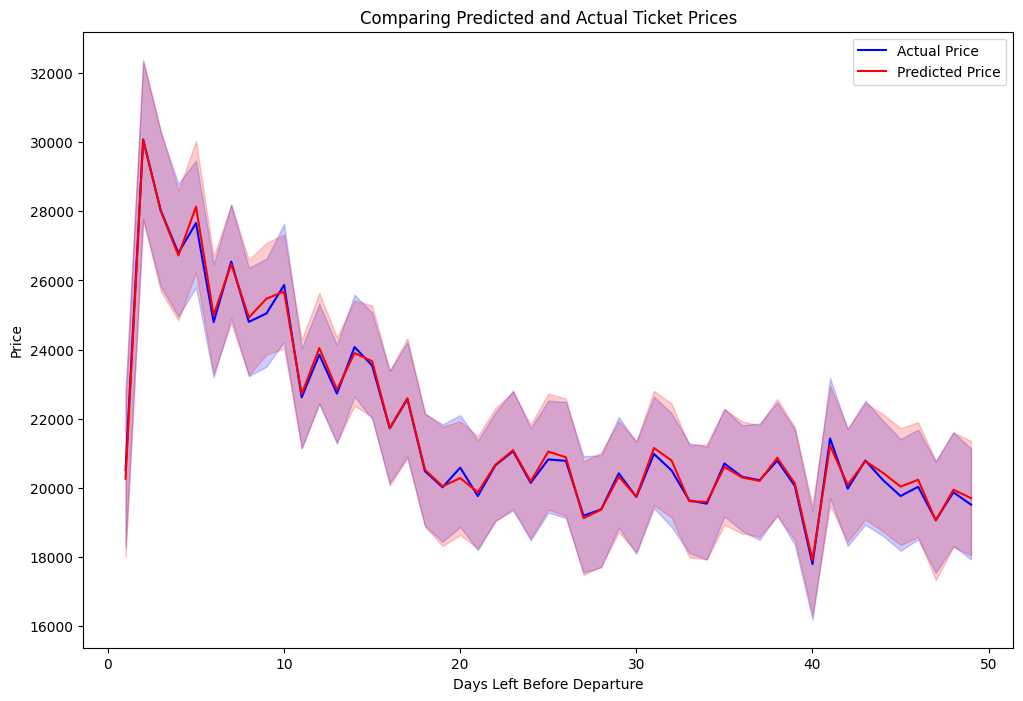

In [38]:
plt.figure(figsize = (12,8))
sns.lineplot(X_test,
            x = 'days_left',
            y = 'actual_price',
            color = 'blue',
            label = 'Actual Price')

sns.lineplot(X_test,
            x = 'days_left',
            y = 'predicted_price',
            color = 'red',
            label = 'Predicted Price',
            errorbar= ('se', 2))

plt.title('Comparing Predicted and Actual Ticket Prices')
plt.xlabel('Days Left Before Departure')
plt.legend()
plt.ylabel('Price')